In [24]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path

In [25]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot"
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" #
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" #
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

# Circular Layout

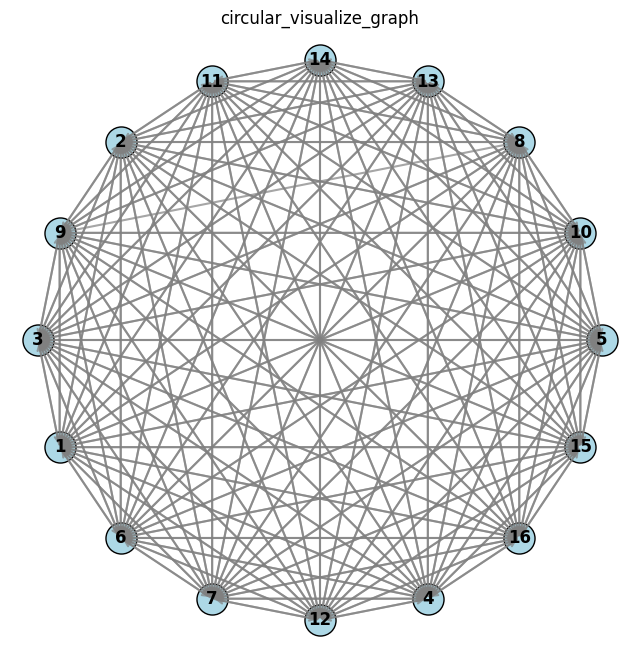

In [26]:
def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("circular_visualize_graph")
    plt.show()

#use a file
dot_file = data_name_7 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)


# Resolve Cycle using Trivial Heuristic

In [37]:
def find_loops(nodes, edges):
    """
    Find all distinct cycles in a directed graph using NetworkX.
    
    Args:
        nodes: List of nodes in the graph
        edges: List of edges as tuples (source, destination)
        
    Returns:
        list: All distinct cycles found in the graph
    """
    # Create a directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    # Find all simple cycles
    cycles = list(nx.simple_cycles(G))
    
    return cycles

def trivial_feedback_arc_set(nodes, edges):
    """
    Trivial heuristic to find a feedback arc set.
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        A: list of edges to keep as they are
        A_reverse: list of edges to be reversed
    """
    # Create the graph as a dictionary {node: [adjacent_nodes]}
    graph = {node: [] for node in nodes}
    for source, target in edges:
        if source in graph:
            graph[source].append(target)
    
    # Create lists to store the edges
    A = []          # edges to keep
    A_reverse = []  # edges to reverse
    
    # Calculate indegree for each node
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            if neighbor in in_degree:  # Ensure the node exists in the dictionary
                in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Continue until there are no nodes left in the graph
    while graph:
        # Step 1: Find sink and source nodes
        sinks = [node for node in graph if not graph[node]]
        sources = [node for node in graph if in_degree[node] == 0]
        
        # Step 2: Remove sink nodes
        while sinks:
            sink = sinks.pop()
            # Add the incoming edges of the sink to A
            for node in list(graph.keys()):
                if sink in graph[node]:
                    A.append((node, sink))
                    graph[node].remove(sink)
                    in_degree[sink] -= 1
            # Remove the sink node from the graph
            del graph[sink]
        
        # Step 3: Remove isolated nodes
        isolated = [node for node in graph if not graph[node] and in_degree[node] == 0]
        for node in isolated:
            del graph[node]
        
        # Step 4: Remove source nodes
        while sources:
            source = sources.pop()
            # Add the outgoing edges of the source to A
            for neighbor in list(graph[source]):
                A.append((source, neighbor))
                graph[source].remove(neighbor)
                in_degree[neighbor] -= 1
                # Check if the neighbor has become a source
                if in_degree[neighbor] == 0 and neighbor in graph and neighbor not in sources:
                    sources.append(neighbor)
            # Remove the source node from the graph
            del graph[source]
        
        # Step 5: If there are still nodes, select the one with max(outdegree - indegree)
        if graph:
            # Calculate outdegree - indegree for each node
            diff_degree = {node: len(graph[node]) - in_degree[node] for node in graph}
            
            # Find the node with the maximum difference
            max_diff_node = max(diff_degree, key=diff_degree.get)
            
            # Add the node's edges to A_reverse
            for neighbor in list(graph[max_diff_node]):
                A_reverse.append((max_diff_node, neighbor))
                graph[max_diff_node].remove(neighbor)
                in_degree[neighbor] -= 1
            
            # Remove the node from the graph
            del graph[max_diff_node]
    
    return A, A_reverse

def reversed_edges(A, A_reverse):
    """Return the reversed edges that solve the loops"""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    final_reversed = A_reversed + A
    
    return final_reversed

def circular_reverse_graph(nodes, edges, E_unchanged=None):
    """
    Plot the directed graph using Matplotlib.
    
    Parameters:
        nodes: List of nodes
        edges: List of all edges
        E_unchanged: List of edges that were not changed (to be drawn in black)
    """
    if E_unchanged is None:
        E_unchanged = []
    
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        
        # Check if edge is in E_unchanged
        if (src, dst) in E_unchanged:
            edge_color = "black"  # Unchanged edges in black
        else:
            edge_color = "red"    # Changed edges in red
            
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


    plt.title("Circular Graph Visualization")
    plt.show()


# League Network


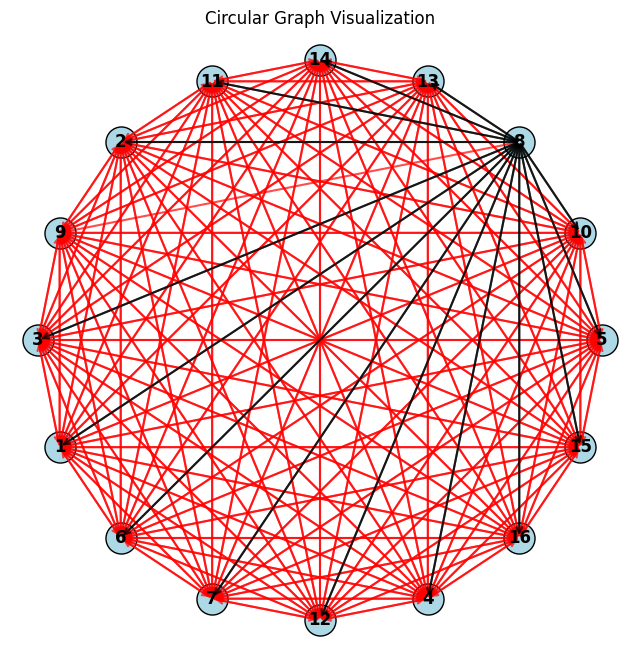

In [38]:
dot_file = data_name_7
nodes, edges = parse_dot_file(dot_file)

# Apply the trivial feedback arc set heuristic
A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)

# Visualize the graph with reversed edges
circular_reverse_graph(nodes, final_edges, A)

# Noname Network

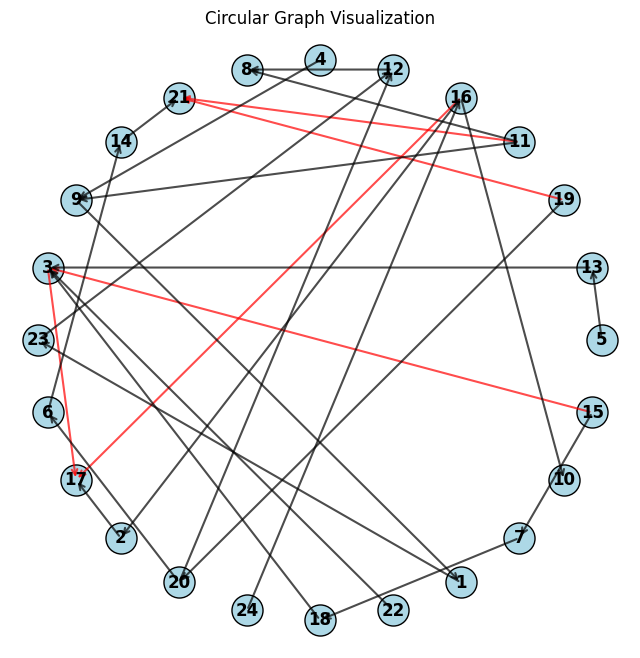

In [39]:
dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

# Apply the trivial feedback arc set heuristic
A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)

# Visualize the graph with reversed edges
circular_reverse_graph(nodes, final_edges, A)

# Layer Assignment

In [40]:
def find_sources(nodes, edges):
    """
    Find source nodes (nodes with no incoming edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of source nodes.
    """
    # Create a set of all nodes (from input nodes and those mentioned in edges)
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Initialize incoming edge counts
    incoming_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        incoming_edges[dst] += 1.
    return [node for node, count in incoming_edges.items() if count == 0]

def add_dummy_nodes(layers, edges):
    """
    Add dummy nodes for edges that span multiple layers.
    """
    # Create node to layer mapping
    node_to_layer = {}
    for i, layer in enumerate(layers):
        for node in layer:
            node_to_layer[node] = i
    
    modified_layers = [layer[:] for layer in layers]
    modified_edges = []
    dummy_mapping = {}  # Maps dummy nodes to original edges
    dummy_counter = 0
    
    for source, target in edges:
        source_layer = node_to_layer[source]
        target_layer = node_to_layer[target]
        
        if target_layer - source_layer > 1:
            # Edge spans multiple layers, need dummy nodes
            current = source
            for layer_idx in range(source_layer + 1, target_layer):
                dummy_name = f"dummy_{dummy_counter}"
                dummy_counter += 1
                
                # Add dummy node to layer
                modified_layers[layer_idx].append(dummy_name)
                
                # Add edge to dummy node
                modified_edges.append((current, dummy_name))
                dummy_mapping[dummy_name] = (source, target)
                current = dummy_name
            
            # Connect last dummy node to target
            modified_edges.append((current, target))
        else:
            modified_edges.append((source, target))
    
    return modified_layers, modified_edges, dummy_mapping

def sugiyama_layer_assignment(nodes, edges):
    """
    Enhanced Sugiyama layer assignment with dummy nodes.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    layers = []  # Stores the final layers
    remaining_nodes = all_nodes.copy()
    remaining_edges = edges.copy()

    # Initial layer assignment
    while remaining_nodes:
        sources = find_sources(remaining_nodes, remaining_edges)
        
        if not sources:
            raise ValueError("Graph contains cycles or is disconnected.")
        
        layers.append(sources)
        remaining_nodes -= set(sources)
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    # Add dummy nodes for long edges
    layers_with_dummies, modified_edges, dummy_mapping = add_dummy_nodes(layers, edges)
    
    return layers_with_dummies, modified_edges, dummy_mapping

def draw_layered_graph(layers, edges, dummy_mapping=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Calculate x-positions for nodes in this layer
        num_nodes = len(layer_nodes)
        x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
        
        # Place nodes
        for node_idx, node in enumerate(layer_nodes):
            x = x_positions[node_idx]
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions

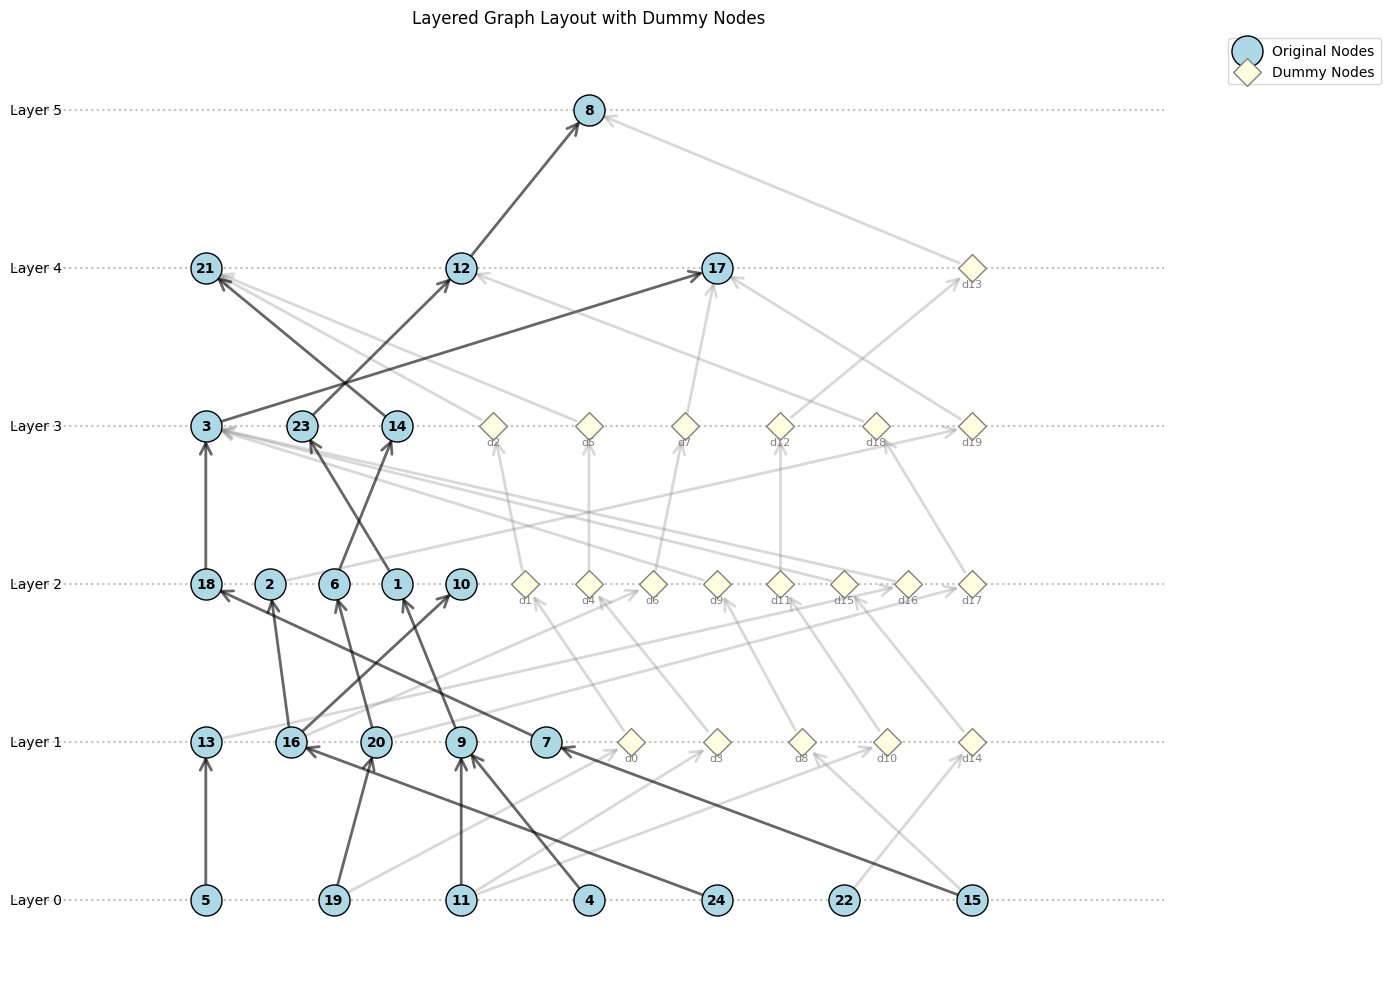

In [41]:
"""#Example usage:
nodes = ['A', 'B', 'C', 'D']
edges = [('A', 'C'), ('A', 'D'), ('B', 'D')]
layers, modified_edges, dummy_mapping = sugiyama_layer_assignment(nodes, edges)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)
plt.show()
"""
# Testing with LeagueNetwork or noname

dot_file = data_name_9 # noname network 
nodes_9, edges_9 = parse_dot_file(dot_file)
#circular_visualize_graph(nodes, edges)

A_9, A_reverse_9 = trivial_feedback_arc_set(nodes_9, edges_9)

final_edges_9 = reversed_edges(A_9, A_reverse_9)

layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes_9, final_edges_9)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)
plt.show()

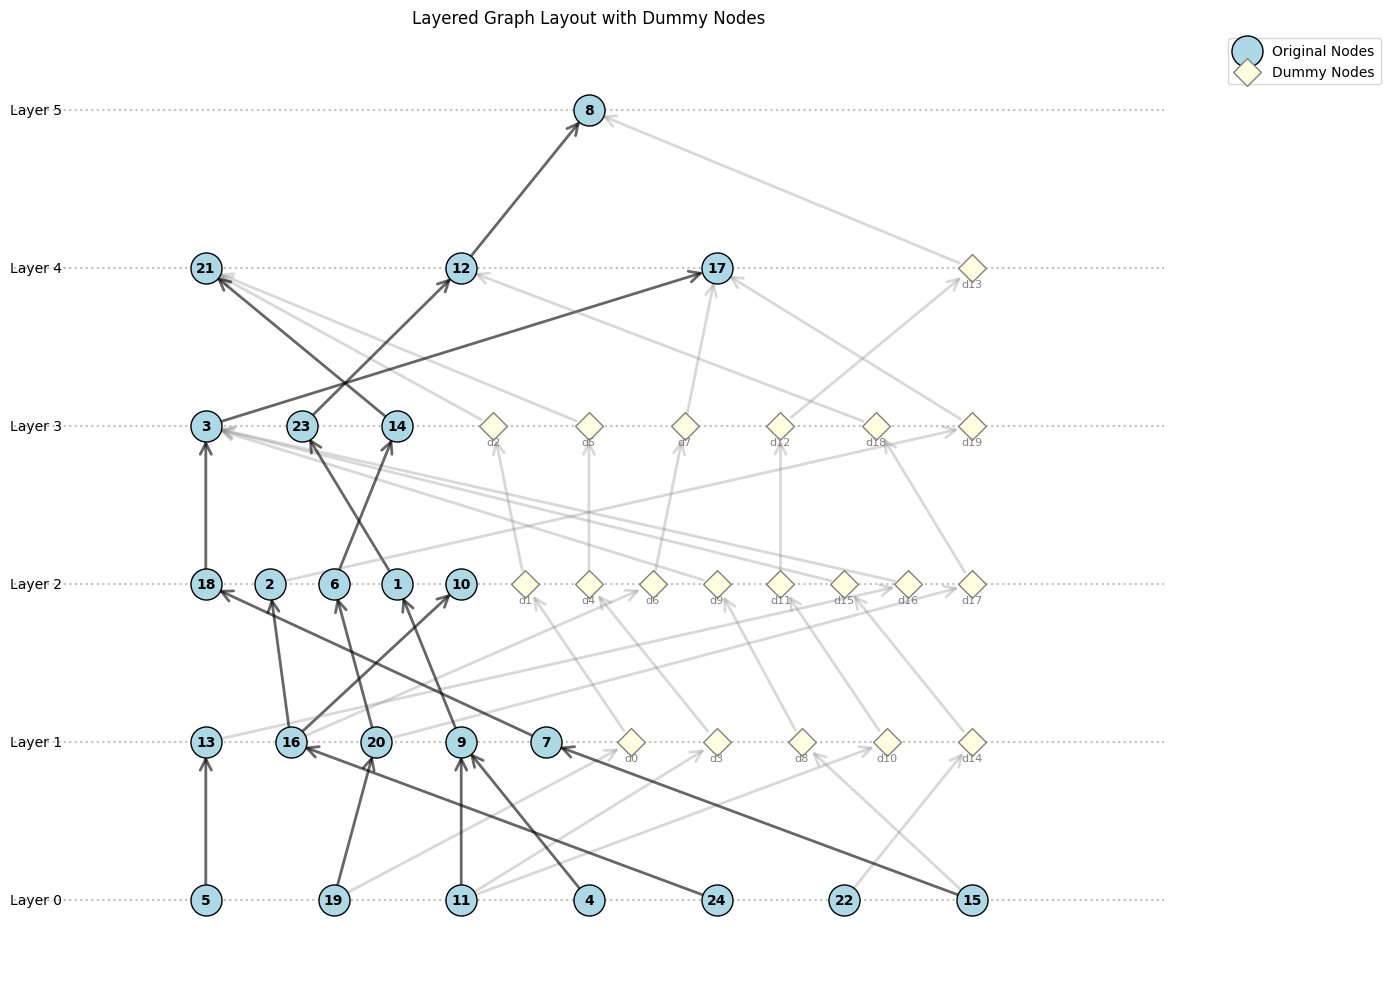

In [42]:
layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes, final_edges)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)
plt.show()

In [36]:
# Testing with LeagueNetwork 

dot_file = data_name_7 # noname network 
nodes_7, edges_7 = parse_dot_file(dot_file)
#circular_visualize_graph(nodes, edges)

A_7, A_reverse_7 = trivial_feedback_arc_set(nodes_7, edges_7)

final_edges_7 = reversed_edges(A_7, A_reverse_7)

layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes_7, final_edges_7)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)
plt.show()

ValueError: Graph contains cycles or is disconnected.

# Cross Minimizing

In [34]:
def get_node_order(layer):
    """Helper function to get the current order of nodes in a layer"""
    return {node: idx for idx, node in enumerate(layer)}

def get_median_position(node, connected_nodes, node_order):
    """Calculate median position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    positions = sorted([node_order[n] for n in connected_nodes])
    n = len(positions)
    if n % 2 == 1:
        return positions[n // 2]
    return (positions[(n-1) // 2] + positions[n // 2]) / 2

def get_barycenter_position(node, connected_nodes, node_order):
    """Calculate barycenter position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    return sum(node_order[n] for n in connected_nodes) / len(connected_nodes)

def minimize_crossings(layers, edges, max_iterations=10, method='barycenter'):
    """
    Minimize edge crossings using either barycenter or median heuristic
    Args:
        layers: List of layers, each containing nodes
        edges: List of (source, target) edge tuples
        max_iterations: Maximum number of sweep iterations
        method: 'barycenter' or 'median'
    """
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    for iteration in range(max_iterations):
        improved = False
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            # Calculate positions for nodes in current layer
            positions = []
            for node in current_layer:
                pos = position_func(node, predecessors[node], fixed_order)
                positions.append((pos, node))
            
            # Sort layer by calculated positions
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            # Calculate positions for nodes in current layer
            positions = []
            for node in current_layer:
                pos = position_func(node, successors[node], fixed_order)
                positions.append((pos, node))
            
            # Sort layer by calculated positions
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        if not improved:
            break
    
    return layers

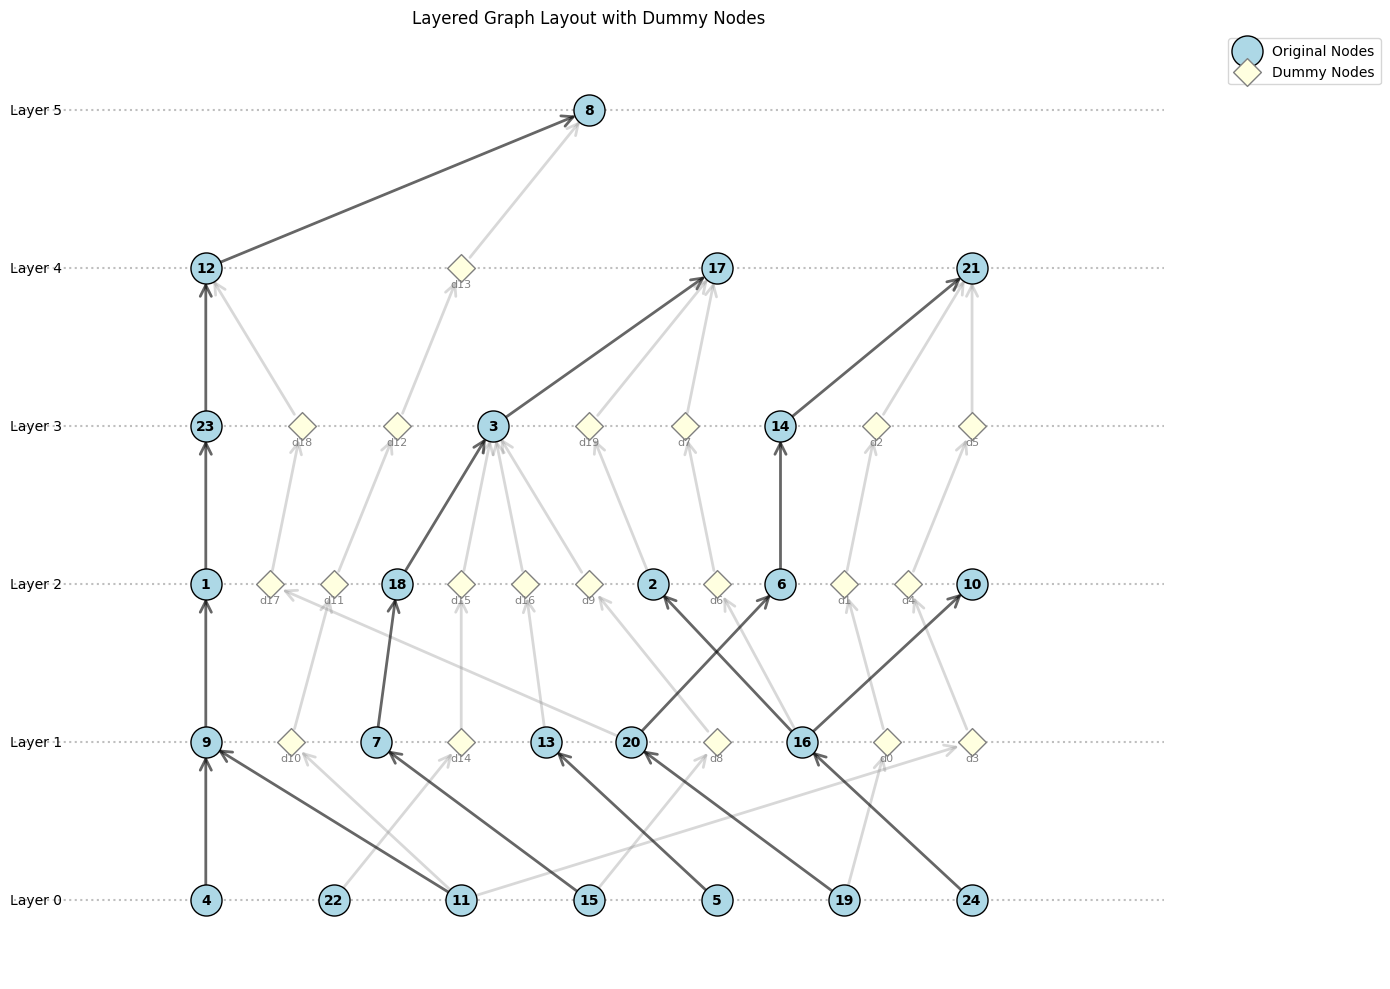

In [23]:
#apply the crossing minimization to the LeagueNetwork or noname network

layers, modified_edges, dummy_mapping = sugiyama_layer_assignment(nodes_9, final_edges_9)

# Apply crossing minimization
optimized_layers = minimize_crossings(
    layers=layers.copy(),  # Create a copy to preserve original
    edges=modified_edges,
    max_iterations=10,
    method='barycenter'  # or 'median'
)

# Visualize the result
positions = draw_layered_graph(optimized_layers, modified_edges, dummy_mapping)
plt.show()

# Node Positioning
